In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [10]:
df_test_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\test_logit_open.csv')
df_test_close = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\test_logit_close.csv')

In [11]:
def expected_value(p, o):
    EV = p * (o - 1) - (1 - p) * 1
    return EV 

def log_return_volatility(f, b, p):
    """
    Compute per-bet log-return volatility (sigma) and expected log return (mu).
    
    f : fraction of bankroll bet
    b : net odds (decimal odds - 1)
    p : probability of winning
    """
    r_win = np.log(1 + f * b)
    r_lose = np.log(1 - f)
    mu = p * r_win + (1 - p) * r_lose
    sigma2 = p * (r_win - mu)**2 + (1 - p) * (r_lose - mu)**2
    sigma = np.sqrt(sigma2)
    return sigma, mu

def expected_max_drawdown(sigma, N):
    """
    Heuristic for expected maximum drawdown over N bets
    """
    return sigma * np.sqrt(2 * np.log(N))

def scale_kelly_for_mdd(p, odds, f_full, N, max_drawdown, tol=1e-4):
    """
    Find the largest fraction of full Kelly that keeps expected MDD <= max_drawdown
    
    p : probability of winning
    odds : decimal odds
    f_full : full Kelly fraction (fraction of bankroll)
    N : number of bets
    max_drawdown : tolerable drawdown fraction (0 < max_drawdown < 1)
    tol : numerical tolerance for convergence
    """
    b = odds - 1
    # binary search between 0 and 1 (fraction of full Kelly)
    low, high = 0.0, 1.0
    best_fraction = 0.0
    
    while high - low > tol:
        k = (low + high) / 2
        f_trial = k * f_full
        sigma, mu = log_return_volatility(f_trial, b, p)
        mdd_est = expected_max_drawdown(sigma, N)
        
        if mdd_est <= max_drawdown:
            best_fraction = k  # this fraction is safe, try higher
            low = k
        else:
            high = k  # too aggressive, try lower
    return best_fraction * f_full



In [ ]:
def kelly_edge(p, fair_decimal):
    edge = p - (1/(fair_decimal))
    return edge

def parlay_top_ev(data, bankroll, top_n=2):
    
    df_top_n = data.sort_values(by='choice_ev', ascending=False).iloc[:top_n]

    parlay_win = True
    parlay_kelly = df_top_n['choice_fstar'].values.sum()
    net_odds = np.prod(df_top_n['choice_real_odds'])-1

    for _, row in df_top_n.iterrows():
        if row['winner'] != row['pred_winner']:
            parlay_win = False

    if parlay_win is True:
        profit = bankroll * parlay_kelly * net_odds
    else: 
        profit = bankroll * parlay_kelly * -1

    return profit 

def run_per_bet_scaling(choice_ev, choice_proba, unweighted_fstar, choice_fair_odds,
                         max_drawdown, bankroll, choice_real_odds, choice_idx, winner_col,
                          group, group_stats, N, group_profit):

    for i, (f_star, p, fair_odds, real_odds, ev, bet_idx) in enumerate(zip(unweighted_fstar, choice_proba, choice_fair_odds, 
                                                                            choice_real_odds, choice_ev, choice_idx)):
        if f_star < 0 or ev < 0:                 
            profit = 0
            f_final = f_star
            net_odds = 0
        else:
            f_final = scale_kelly_for_mdd(p, fair_odds, f_star, N=N, max_drawdown=max_drawdown)  
            stake = bankroll * f_final

            rand_win = np.random.rand()
            winning_bet = True if rand_win <= p else False 
            profit = stake * (real_odds - 1) if winning_bet else -stake
            net_odds = (real_odds - 1) if winning_bet else -1

        group_stats['choice_fstar'].append(f_final)
        group_stats['fight_payout'].append(profit)
        group_stats['net_odds'].append(net_odds)
        group_profit += profit

    return group_stats, group_profit


def simulate_kelly(df_final, prob_cols, fair_decimal_cols, real_decimal_cols,
                           pred_winner_col='pred_winner', winner_col='winner', date_col='date',
                           init_bankroll=1000, max_drawdown=.30, N=1000,
                            calc_parlay=False, test_other_ev = False):
                            
    bankroll = init_bankroll
    df_results = pd.DataFrame()
    df = df_final.sort_values(by=date_col)

    bankroll_history = []

    for date, group in df.groupby(date_col, sort=True):
        group = group.reset_index(drop=True)

        group_profit = 0
        unweighted_fstar = []
        group_stats = {'fight_payout':[], 'choice_fstar':[], 'net_odds':[]}
        choice_ev = []
        choice_proba = []
        choice_real_odds = []
        choice_fair_odds = []
        choice_idx = []

        for idx, row in group.iterrows():
            bet_idx = int(row[pred_winner_col])
            p = row[prob_cols[bet_idx]]
            fair_odds = row[fair_decimal_cols[bet_idx]]
            real_odds = row[real_decimal_cols[bet_idx]]
            ev = expected_value(p, real_odds)

            if ev <= 0 and test_other_ev is True: 
                new_bet = np.abs(bet_idx -1)
                ev = expected_value(1-p, row[real_decimal_cols[new_bet]])
                if ev > 0: 
                    bet_idx = new_bet
                    real_odds = row[real_decimal_cols[bet_idx]]
                    fair_odds = row[fair_decimal_cols[bet_idx]]
                    p = 1-p
                        
            kelly_default = kelly_edge(p, fair_odds) 
            unweighted_fstar.append(kelly_default)
            choice_proba.append(p)
            choice_fair_odds.append(fair_odds)
            choice_real_odds.append(real_odds)
            choice_ev.append(ev)
            choice_idx.append(bet_idx)

        group_stats, group_profit = run_per_bet_scaling(choice_ev, choice_proba, unweighted_fstar, choice_fair_odds, max_drawdown, 
                                            bankroll, choice_real_odds, choice_idx, winner_col, 
                                            group, group_stats, N, group_profit)

        parlay_net = 0
        if calc_parlay is True: 
            df_data = pd.DataFrame({'winner':group['winner'], 'pred_winner':group['pred_winner'], 'choice_ev':choice_ev,
                                    'choice_real_odds' : choice_real_odds, 'choice_fstar':group_stats['choice_fstar']})
            parlay_net = parlay_top_ev(df_data, bankroll, top_n=2)   

        bankroll += group_profit
        bankroll_history.append(bankroll)
        if bankroll <= 0:
            print(f"Bankroll depleted on {date}. Ending simulation.")
            return bankroll_history

    return bankroll_history


def monte_carlo_kelly_sim(df_final, prob_cols, fair_decimal_cols, real_decimal_cols,
                           pred_winner_col='pred_winner', winner_col='winner', date_col='date',
                           init_bankroll=1000, max_drawdown=.30, N=1000,
                            calc_parlay=False, test_other_ev = False, num_simulations=100):
    
    all_histories = []
    for sim in range(num_simulations):
        history = simulate_kelly(df_final, prob_cols, fair_decimal_cols, real_decimal_cols,
                           pred_winner_col, winner_col, date_col,
                           init_bankroll, max_drawdown, N,
                            calc_parlay, test_other_ev)
        all_histories.append(history)

    
    return all_histories     
                          
def analyze_monte_carlo_results(all_histories, init_bankroll=2000):
    """
    Given a list of bankroll histories, compute:
    - probability of total loss (final value = 0)
    - mean final bankroll
    - 95% confidence interval for final bankroll
    - plots of histories + histogram with quantiles
    """

    final_values = np.array([hist[-1] for hist in all_histories])
    N = len(all_histories)

    prob_loss = np.mean(final_values <= init_bankroll)
    mean_final = np.mean(final_values)
    se = np.std(final_values, ddof=1) / np.sqrt(N)

    ci_low = mean_final - 1.96 * se
    ci_high = mean_final + 1.96 * se

    results = {
        "prob_loss": prob_loss,
        "mean_final": mean_final,
        "ci_95": (ci_low, ci_high)
    }

    # Quantiles
    quants = np.percentile(final_values, [5, 25, 50, 75, 95])
    labels = ["5%", "25%", "50%", "75%", "95%"]
    vmin, vmax = final_values.min(), final_values.max()
    vmedian = np.median(final_values)

    # ----------- PLOTS -----------
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))

    # ----------- Subplot 1: bankroll histories -----------
    ax1 = axes[0]
    for hist in all_histories:
        ax1.plot(hist, alpha=0.25)

    ax1.set_title(
        f"Monte Carlo Bankroll Histories (N={N})\n"
        f"Prob Loss: {prob_loss:.5f}, Mean Final: {mean_final:.2f}, "
        f"95% CI: ({ci_low:.2f}, {ci_high:.2f})"
    )
    ax1.set_xlabel("Bet Number")
    ax1.set_ylabel("Bankroll")

    # ----------- Subplot 2: histogram -----------
    ax2 = axes[1]
    sns.histplot(final_values, kde=True, bins=30, ax=ax2)

    # Title with min/max
    ax2.set_title(
        f"Distribution of Final Bankroll Values (min={vmin:.2f}, max={vmax:.2f}, median={vmedian:.2f})"
    )

    ax2.set_xlabel("Final Bankroll")
    ax2.set_ylabel("Frequency")

    # y-axis height for label spacing
    ymax = ax2.get_ylim()[1]

    # Add quantile lines with spaced labels
    vertical_offset_step = ymax * 0.05  # 5% vertical spacing

    for i, (val, label) in enumerate(zip(quants, labels)):
        ax2.axvline(val, color="red", linestyle="--")
        ax2.text(
            val,
            ymax - (i + 1) * vertical_offset_step,  # staggered Y positions
            label,
            rotation=90,
            verticalalignment="top",
            horizontalalignment="center",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
        )

    plt.tight_layout()
    plt.show()

    return results

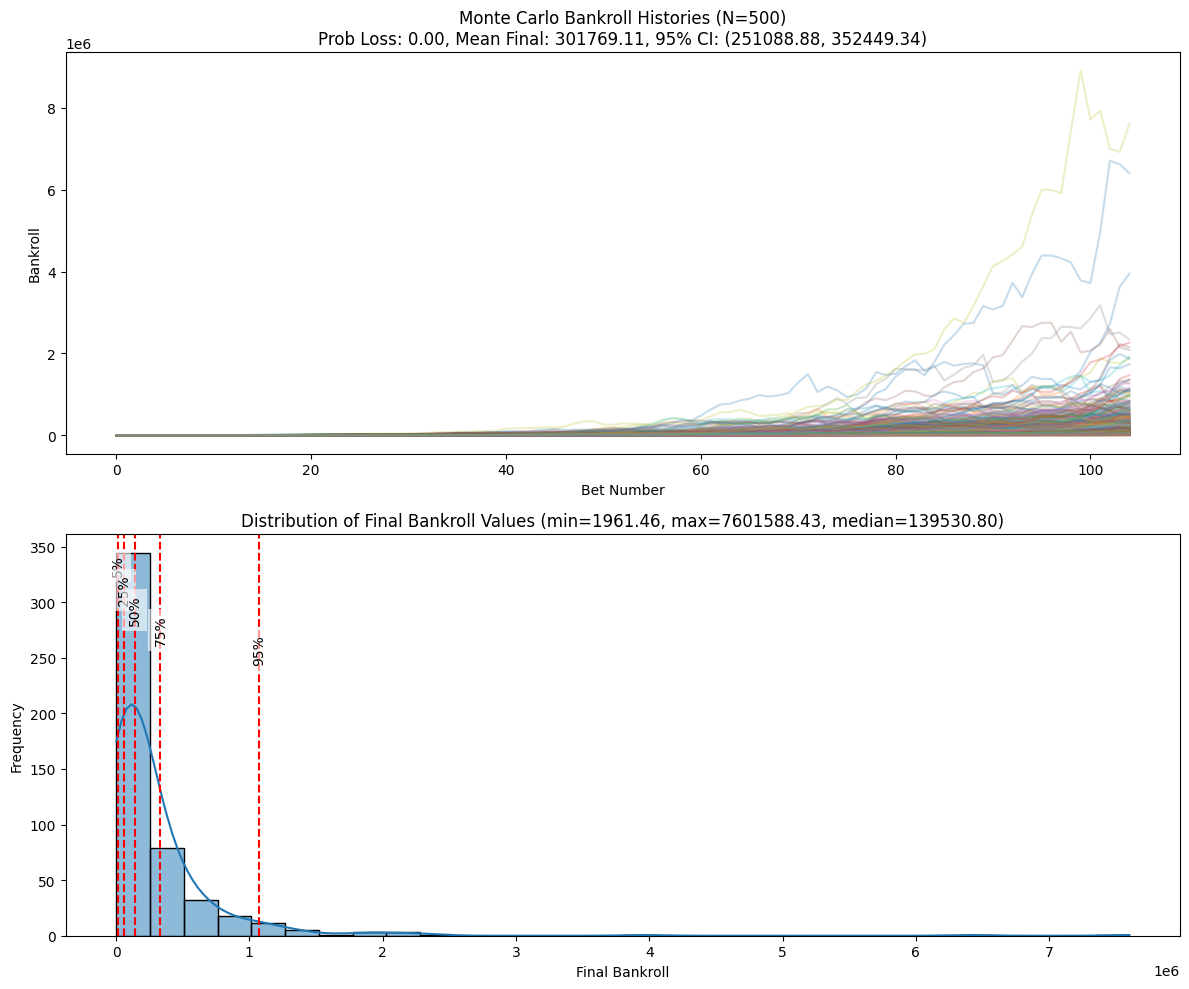

{'prob_loss': np.float64(0.002),
 'mean_final': np.float64(301769.1086986383),
 'ci_95': (np.float64(251088.88099792204), np.float64(352449.3363993545))}

In [59]:
model_probs = ['proba_blue', 'proba_red']
fair_decimal_odds = ['dec_fair_open_blue', 'dec_fair_open_red'] 
real_decimal_odds = ['dec_open_blue', 'dec_open_red']


results_open = monte_carlo_kelly_sim(df_test_open, model_probs, fair_decimal_odds, real_decimal_odds,
                           pred_winner_col='pred_winner', winner_col='winner', date_col='date',
                           init_bankroll=2000, max_drawdown=.30, N=1000,    
                            calc_parlay=False, test_other_ev = False, num_simulations=500)

analyze_monte_carlo_results(results_open)

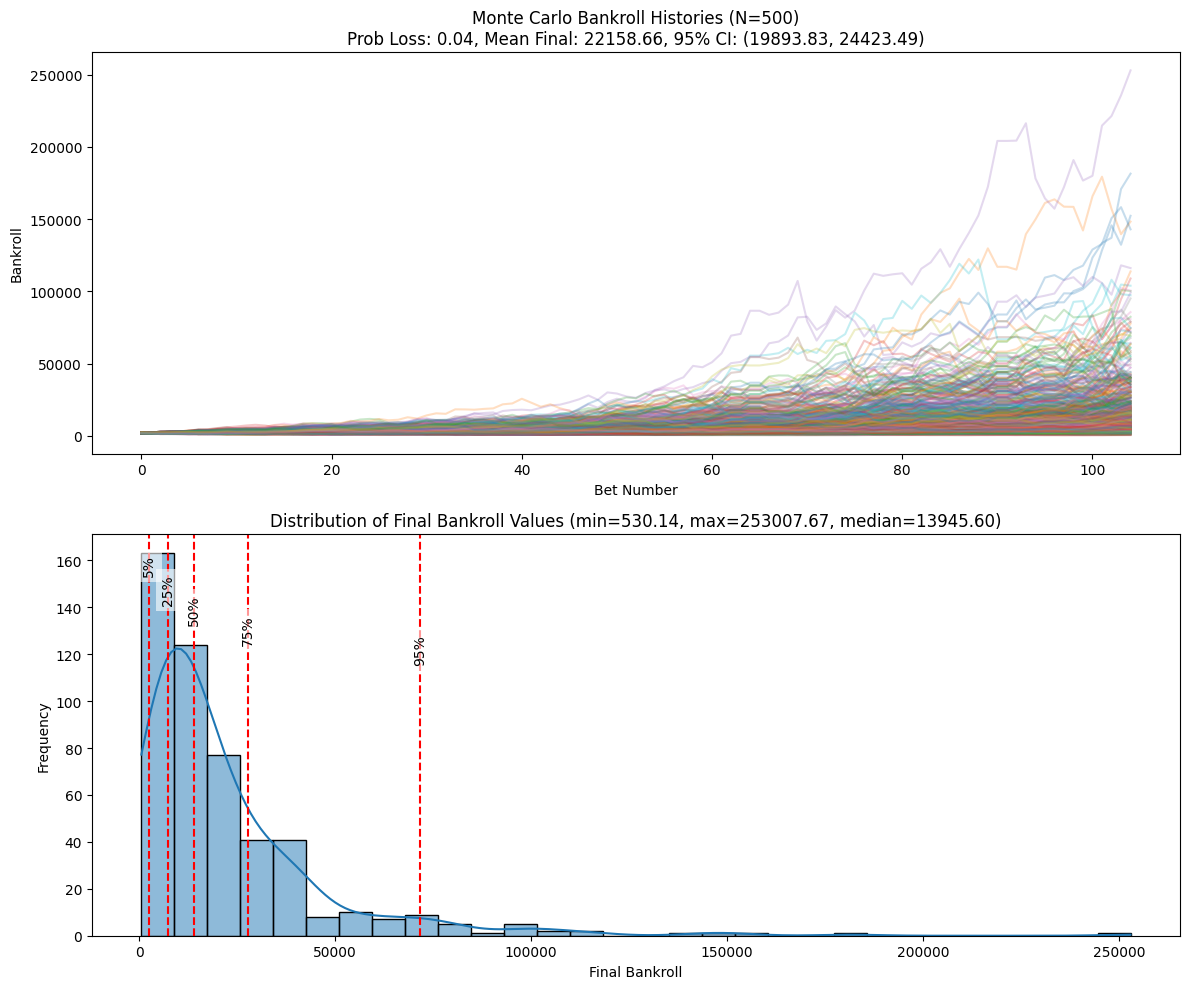

{'prob_loss': np.float64(0.038),
 'mean_final': np.float64(22158.660085664706),
 'ci_95': (np.float64(19893.826566031705), np.float64(24423.493605297706))}

In [60]:
model_probs = ['proba_blue', 'proba_red']
fair_decimal_odds = ['dec_fair_close1_blue', 'dec_fair_close1_red'] 
real_decimal_odds = ['dec_close1_blue', 'dec_close1_red']


results_close1 = monte_carlo_kelly_sim(df_test_close, model_probs, fair_decimal_odds, real_decimal_odds,
                           pred_winner_col='pred_winner', winner_col='winner', date_col='date',
                           init_bankroll=2000, max_drawdown=.30, N=1000,    
                            calc_parlay=False, test_other_ev = False, num_simulations=500)

analyze_monte_carlo_results(results_close1)

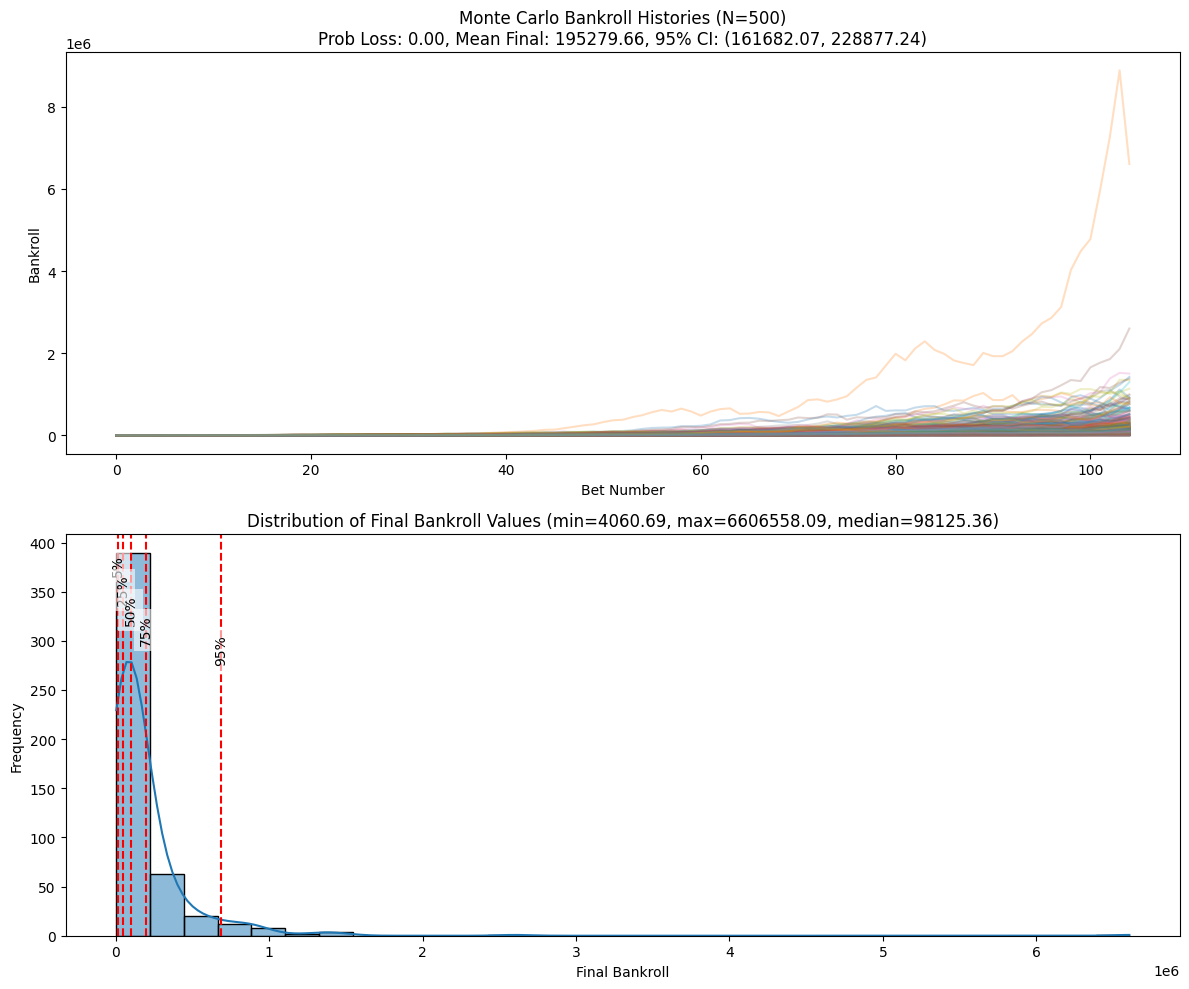

{'prob_loss': np.float64(0.0),
 'mean_final': np.float64(195279.65888492274),
 'ci_95': (np.float64(161682.07357746904), np.float64(228877.24419237644))}

In [57]:
model_probs = ['proba_blue', 'proba_red']
fair_decimal_odds = ['dec_fair_close2_blue', 'dec_fair_close2_red'] 
real_decimal_odds = ['dec_close2_blue', 'dec_close2_red']


results_close1 = monte_carlo_kelly_sim(df_test_close, model_probs, fair_decimal_odds, real_decimal_odds,
                           pred_winner_col='pred_winner', winner_col='winner', date_col='date',
                           init_bankroll=2000, max_drawdown=.30, N=1000,    
                            calc_parlay=False, test_other_ev = False, num_simulations=500)

analyze_monte_carlo_results(results_close1)